In [1]:
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
import numpy as np
import io
from google.colab import files
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def fft_transform(img_tensor):
    gray = img_tensor.mean(dim=0, keepdim=True)
    fft = torch.fft.fft2(gray)
    fft = torch.fft.fftshift(fft)
    mag = torch.log1p(torch.abs(fft))
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
    return mag.repeat(3, 1, 1)

def preprocess_image(img_bytes, size=299):
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    orig_img = img.copy() # Store original for visualization

    img = img.resize((320, 320), Image.BICUBIC)
    left = (320 - size) // 2
    img = img.crop((left, left, left+size, left+size))

    img_tensor = torch.from_numpy(np.array(img)).permute(2,0,1).float() / 255.0
    fft_img = fft_transform(img_tensor)

    return fft_img.unsqueeze(0), orig_img

In [2]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)

print("Please upload your saved model weights (.pth file):")
uploaded_model = files.upload()
model_path = list(uploaded_model.keys())[0]

checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=True)
if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(DEVICE)
model.eval()
print(f"Model loaded successfully on {DEVICE}")

Please upload your saved model weights (.pth file):


Saving fft_debiased_resnet18_fromscratch.pth to fft_debiased_resnet18_fromscratch.pth
✅ Model loaded successfully on cpu


Please upload one or multiple images for testing:


Saving WhatsApp Image 2026-02-27 at 09.24.31.jpeg to WhatsApp Image 2026-02-27 at 09.24.31.jpeg
File: WhatsApp Image 2026-02-27 at 09.24.31.jpeg -> Prediction: AI (Confidence: 0.6586)


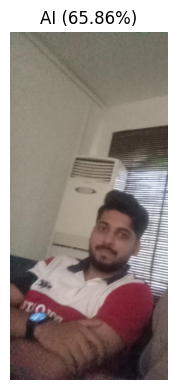

In [10]:
classes = {0: "REAL", 1: "FAKE"}

print("Please upload one or multiple images for testing:")
uploaded_images = files.upload()

results = []
for filename, img_bytes in uploaded_images.items():
    fft_tensor, orig_img = preprocess_image(img_bytes)
    fft_tensor = fft_tensor.to(DEVICE)

    with torch.no_grad():
        logits = model(fft_tensor)
        probs = torch.softmax(logits, dim=1)[0]
        pred_idx = logits.argmax(1).item()
        confidence = probs[pred_idx].item()

    label = classes[pred_idx]
    results.append((filename, label, confidence, orig_img))
    print(f"File: {filename} -> Prediction: {label} (Confidence: {confidence:.4f})")

fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, (fname, label, conf, img) in zip(axes, results):
    ax.imshow(img)
    ax.set_title(f"{label} ({conf:.2%})")
    ax.axis('off')

plt.tight_layout()
plt.show()